# Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import re

# --- Configuration ---
file_path = '/content/nutrition.csv' # <<< IMPORTANT: Update this path >>>

# (Using lists from previous code - verify they match your full dataset)
cols_in_g = ['total_fat', 'saturated_fat', 'protein', 'carbohydrate', 'fiber', 'sugars', 'water', 'ash',
             'fat', 'saturated_fatty_acids', 'monounsaturated_fatty_acids', 'polyunsaturated_fatty_acids',
             'alanine', 'arginine', 'aspartic_acid', 'cystine', 'glutamic_acid', 'glycine',
             'histidine', 'isoleucine', 'leucine', 'lysine', 'methionine', 'phenylalanine',
             'proline', 'serine', 'threonine', 'tryptophan', 'tyrosine', 'valine',
             'fructose', 'galactose', 'glucose', 'lactose', 'maltose', 'sucrose',
             'alcohol', 'hydroxyproline']

cols_in_mg = ['cholesterol', 'sodium', 'choline', 'niacin', 'pantothenic_acid', 'riboflavin',
              'thiamin', 'vitamin_b6', 'vitamin_c', 'vitamin_e', 'tocopherol_alpha',
              'calcium', 'copper', 'iron', 'magnesium', 'manganese', 'phosphorous',
              'potassium', 'zinc', 'fatty_acids_total_trans', 'caffeine', 'theobromine']

cols_in_mcg = ['folate', 'folic_acid', 'vitamin_a_rae', 'carotene_alpha', 'carotene_beta',
               'cryptoxanthin_beta', 'lutein_zeaxanthin', 'vitamin_b12', 'vitamin_k', 'selenium']

cols_in_iu = ['vitamin_a', 'vitamin_d']

TARGET_UNIT_MG = 'mg'
TARGET_UNIT_G = 'g'

problematic_object_cols = ['iron', 'zinc', 'hydroxyproline', 'fructose',
                           'galactose', 'glucose', 'lactose', 'maltose', 'sucrose', 'alcohol']


# --- Function to Clean and Convert ---
def clean_and_convert(value):
    """Removes common units (g, mg, mcg, IU) and converts to numeric."""
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        # Remove units using regex
        cleaned_value = re.sub(r'\s*(g|mg|mcg|IU|kcal)$', '', value, flags=re.IGNORECASE).strip()
        # Handle potential commas
        cleaned_value = cleaned_value.replace(',', '')
        # Handle other common non-numeric representations explicitly if needed
        if cleaned_value.lower() in ['trace', '--', 'n/a', 'na', '']:
             return np.nan # Ensure these become NaN
        return pd.to_numeric(cleaned_value, errors='coerce')
    return np.nan

# --- 1. Load Data ---
print(f"--- Loading Data from {file_path} ---")
try:
    df = pd.read_csv(file_path, index_col=0)
    print(f"Loaded DataFrame shape: {df.shape}")
    # Correct typos before processing
    df.rename(columns={'irom': 'iron', 'zink': 'zinc', 'lucopene': 'lycopene'}, inplace=True, errors='ignore')
except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please update the path.")
    exit()
except Exception as e:
    print(f"An error occurred loading the data: {e}")
    exit()

# Ensure 'name' column exists or handle appropriately
if 'name' not in df.columns and df.index.name == 'name':
     df.reset_index(inplace=True)
elif 'name' not in df.columns:
     print("Warning: 'name' column not found.")


# --- 2. Apply Cleaning and Initial Conversion ---
print("\n--- Cleaning Nutrient Columns ---")
all_nutrient_cols_to_process = cols_in_g + cols_in_mg + cols_in_mcg + cols_in_iu + ['calories']
processed_cols = [] # Keep track of columns we actually processed

for col in all_nutrient_cols_to_process:
    if col in df.columns:
        print(f"Processing: {col}")
        # Apply the cleaning function - Ensure assignment back to the column!
        df[col] = df[col].apply(clean_and_convert)
        processed_cols.append(col)
    # No warning needed here, handled later if col missing

# --- 3. Handle Missing Values ---
print("\n--- Handling Missing Values (NaNs) with 0 ---")
initial_nan_count = df[processed_cols].isnull().sum().sum()
print(f"Total NaNs in processed columns before filling: {initial_nan_count}")
# We fillna *before* the final coercion step
df.fillna(0, inplace=True)

# --- 4. Explicitly Coerce Problematic Columns to Numeric ---
print("\n--- Coercing known problematic columns to numeric AFTER cleaning & fillna ---")
for col in problematic_object_cols:
     if col in df.columns:
         if df[col].dtype == 'object': # Only try if it's still object
             print(f"Attempting coercion for: {col}")
             try:
                 # This will force conversion or raise error if impossible strings remain
                 df[col] = pd.to_numeric(df[col])
                 print(f" -> Successfully coerced {col} to numeric.")
             except ValueError as e:
                 print(f" -> ERROR coercing {col}: {e}")
                 # Find the specific values causing the error:
                 offending_values = df[pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()][col].unique()
                 print(f"   Offending unique values in {col}: {offending_values[:10]}") # Show first 10 offenders
         elif col in processed_cols:
             # If it was processed and is already numeric, that's good.
             print(f"Column {col} is already numeric.")
         # else:
             # If it wasn't in the original processing lists but is problematic, maybe add it?
             # print(f"Warning: Column {col} was problematic but not in initial processing lists.")


# --- Check dtypes AGAIN after coercion ---
print("\nData types AFTER cleaning, fillna, and coercion:")
print(df.info()) # Check if the problematic columns are now numeric

# --- 5. Unit Standardization (Continue as before) ---
print(f"\n--- Standardizing Units (Target: {TARGET_UNIT_G} for macros, {TARGET_UNIT_MG} for micro) ---")
# Convert mcg to mg
converted_mcg_cols = []
for col in cols_in_mcg:
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]): # Check if numeric first
        new_col_name = f"{col}_{TARGET_UNIT_MG}"
        if col != new_col_name:
             df[col] = df[col] / 1000.0
             df.rename(columns={col: new_col_name}, inplace=True)
             converted_mcg_cols.append(new_col_name)
             if col in processed_cols: processed_cols.remove(col)
             if new_col_name not in processed_cols: processed_cols.append(new_col_name) # Track new name
print(f"Converted mcg->mg and renamed: {converted_mcg_cols}")

# Add suffixes
for col_list, suffix in [(cols_in_mg, f"_{TARGET_UNIT_MG}"), (cols_in_g, f"_{TARGET_UNIT_G}")]:
     print(f"Adding '{suffix}' suffix where needed...")
     renamed_cols = []
     for col in col_list:
         if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
             new_col_name = col + suffix if not col.endswith(suffix) else col
             if col != new_col_name:
                 df.rename(columns={col: new_col_name}, inplace=True)
                 renamed_cols.append(new_col_name)
                 if col in processed_cols: processed_cols.remove(col)
                 if new_col_name not in processed_cols: processed_cols.append(new_col_name)
     print(f"Renamed/Checked with {suffix}: {renamed_cols}")


# --- 6. Final Selection and Saving (As before) ---
print("\n--- Finalizing Data for Network Input ---")
if 'name' not in df.columns:
     print("ERROR: 'name' column is missing.")
     exit()

# Rebuild final columns list based on actual columns and suffixes
final_columns = ['name'] + sorted([col for col in df.columns if pd.api.types.is_numeric_dtype(df[col])])
df_final = df[final_columns].copy()
df_final.set_index('name', inplace=True)

print(f"\nFinal DataFrame shape: {df_final.shape}")
print("Final columns included:")
print(df_final.columns.tolist())
print("\nFinal Data Info:")
print(df_final.info()) # Final check! Should all be numeric.

output_file = 'food_data_processed_for_network_v2.csv'
print(f"\n--- Saving Processed Data to {output_file} ---")
df_final.to_csv(output_file, index=True)
print("Done.")

--- Loading Data from /content/nutrition.csv ---
Loaded DataFrame shape: (8789, 76)

--- Cleaning Nutrient Columns ---
Processing: total_fat
Processing: saturated_fat
Processing: protein
Processing: carbohydrate
Processing: fiber
Processing: sugars
Processing: water
Processing: ash
Processing: fat
Processing: saturated_fatty_acids
Processing: monounsaturated_fatty_acids
Processing: polyunsaturated_fatty_acids
Processing: alanine
Processing: arginine
Processing: aspartic_acid
Processing: cystine
Processing: glutamic_acid
Processing: glycine
Processing: histidine
Processing: isoleucine
Processing: leucine
Processing: lysine
Processing: methionine
Processing: phenylalanine
Processing: proline
Processing: serine
Processing: threonine
Processing: tryptophan
Processing: tyrosine
Processing: valine
Processing: fructose
Processing: galactose
Processing: glucose
Processing: lactose
Processing: maltose
Processing: sucrose
Processing: alcohol
Processing: hydroxyproline
Processing: cholesterol
Pro

--- Loading Processed Data from /content/food_data_processed_for_network_v2.csv ---
Loaded DataFrame shape: (8789, 74)

Data Types:
<class 'pandas.core.frame.DataFrame'>
Index: 8789 entries, Cornstarch to Beef, raw, all grades, trimmed to 0" fat, separable lean only, boneless, eye of round steak, round
Data columns (total 74 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   alanine_g                      8789 non-null   float64
 1   alcohol_g                      8789 non-null   float64
 2   arginine_g                     8789 non-null   float64
 3   ash_g                          8789 non-null   float64
 4   aspartic_acid_g                8789 non-null   float64
 5   caffeine_mg                    8789 non-null   float64
 6   calcium_mg                     8789 non-null   float64
 7   calories                       8789 non-null   float64
 8   carbohydrate_g                 8789 non-null   float64
 9 

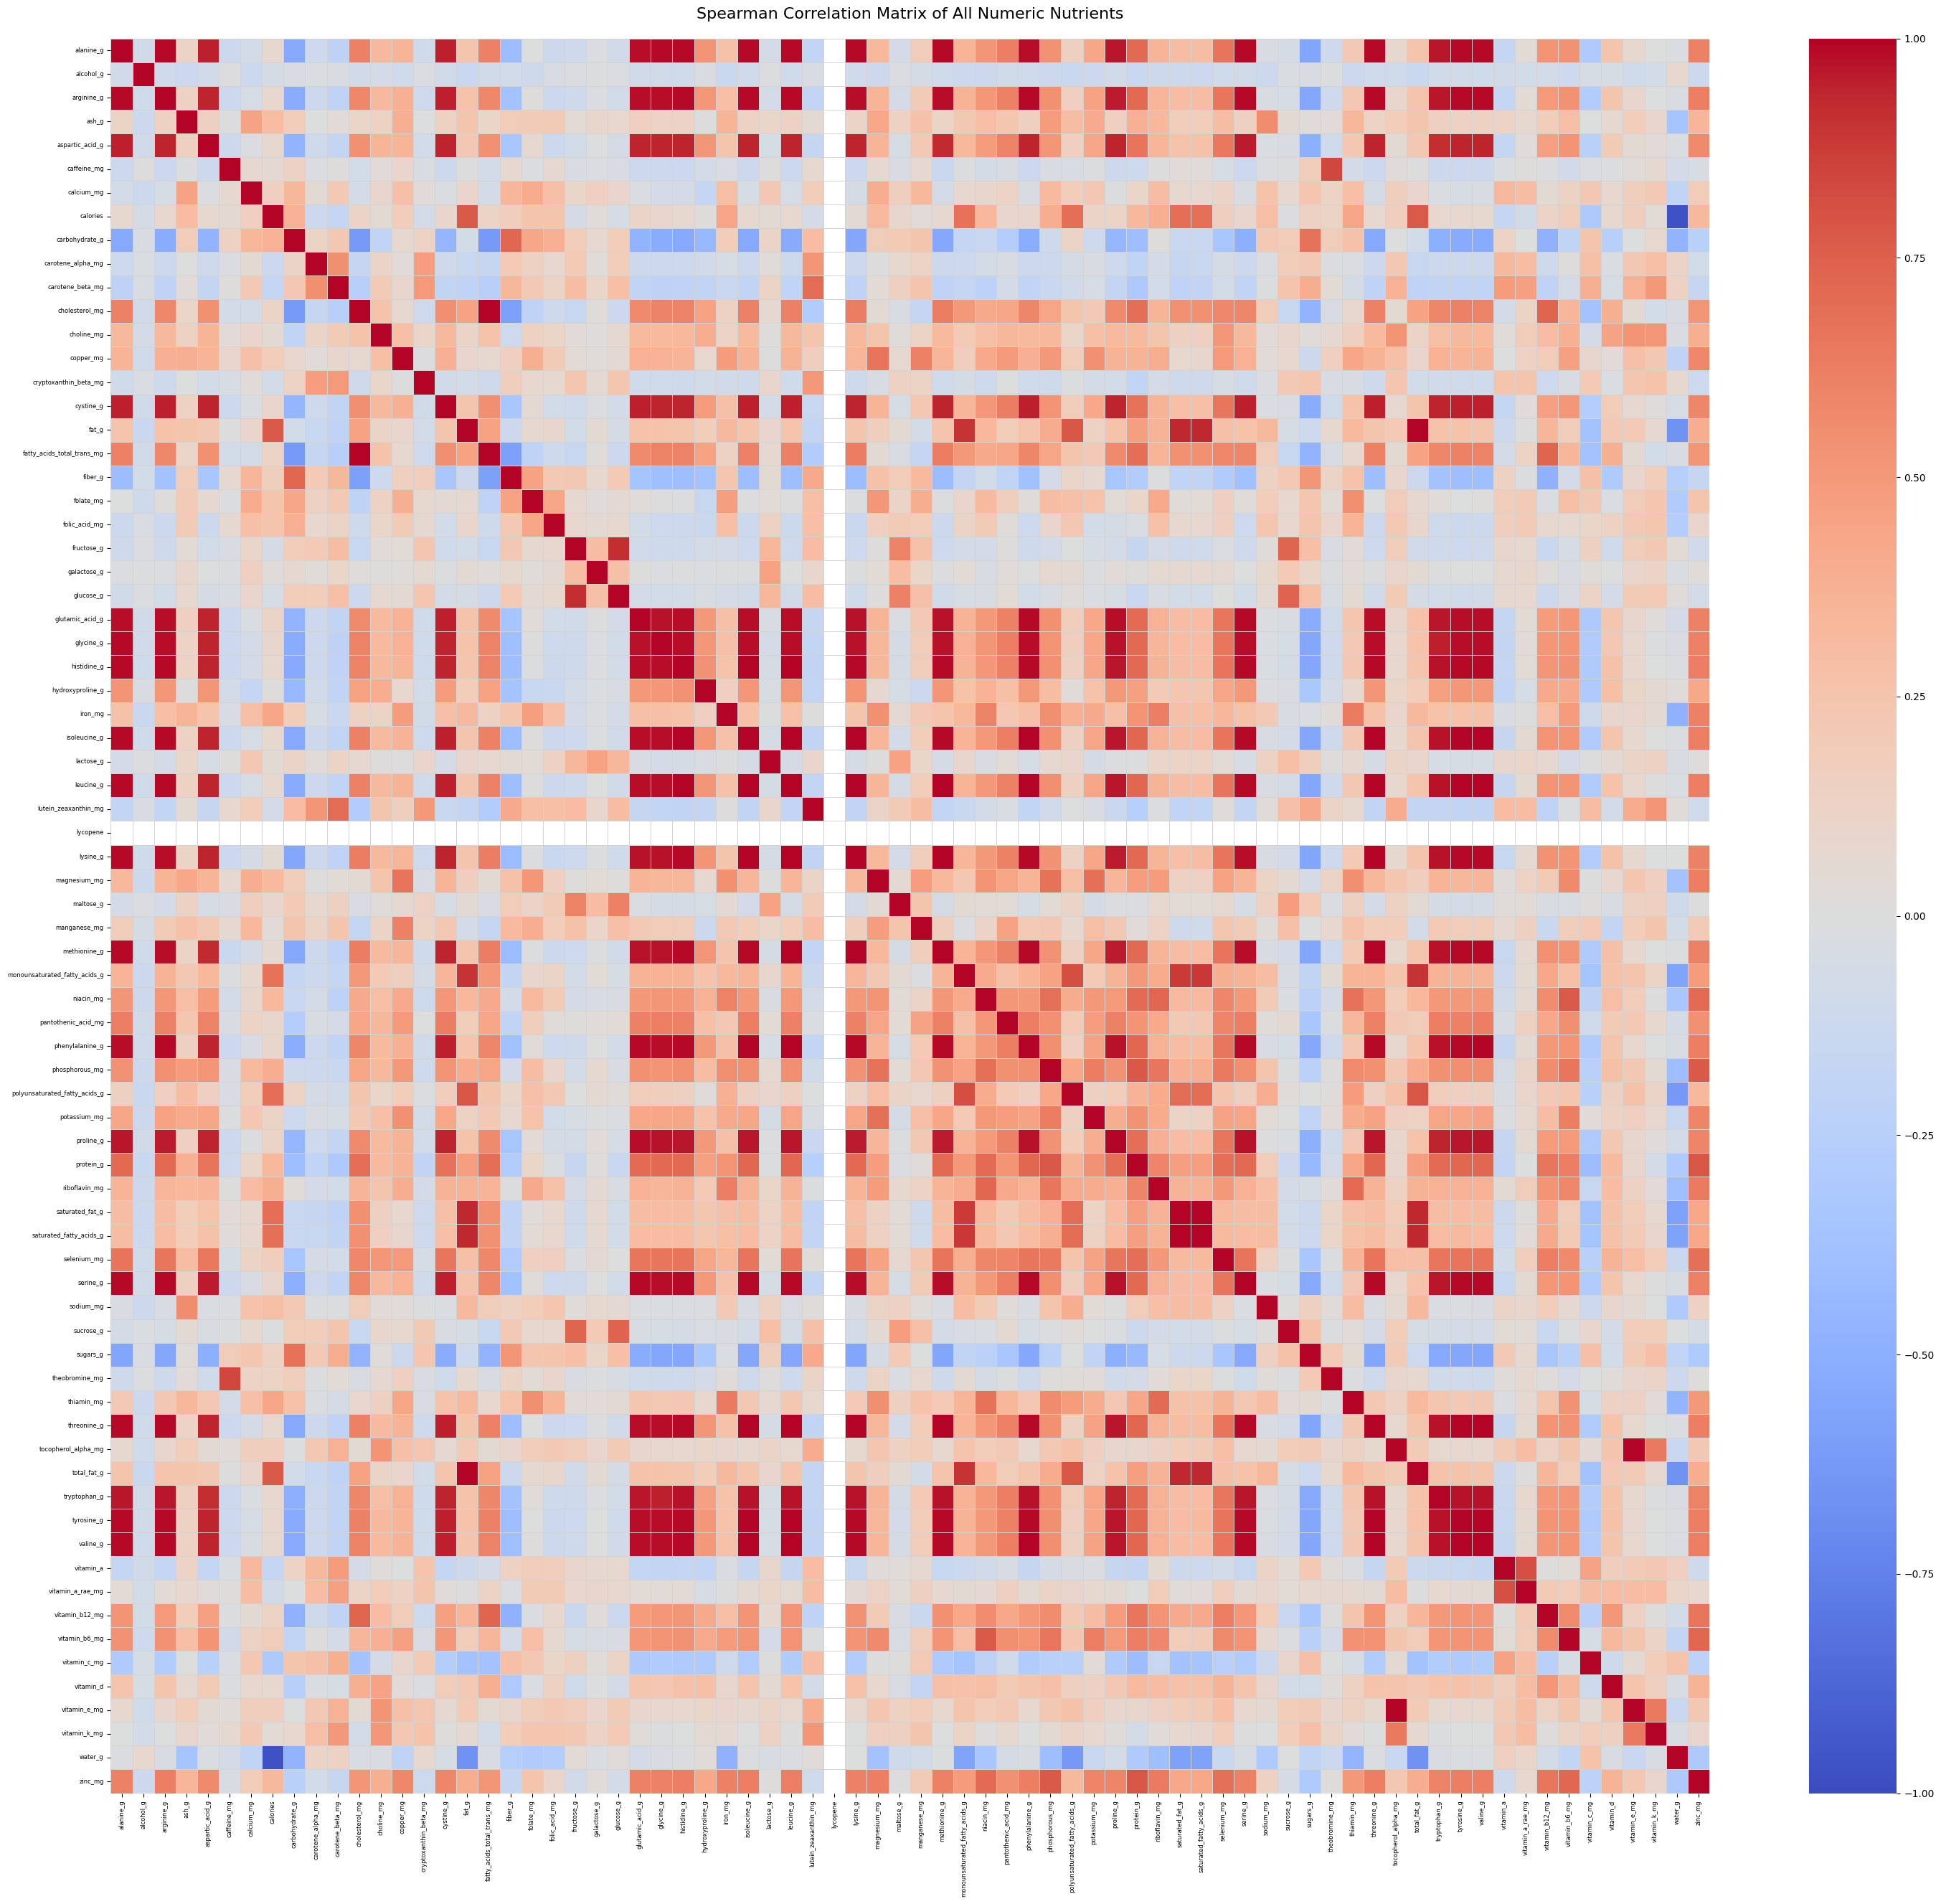


--- Heatmap Displayed ---
Observe the color patterns: 
 - Strong red indicates strong positive correlation (nutrients tend to be high/low together).
 - Strong blue indicates strong negative correlation (one nutrient high when the other is low).
 - White/light colors indicate weak or no correlation.
Look for distinct blocks of color which might represent groups of related nutrients (e.g., macronutrients, specific vitamin groups).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
# <<< Ensure this path points to the CLEANED data from the previous step >>>
processed_file_path = '/content/food_data_processed_for_network_v2.csv'

# --- 1. Load Processed Data ---
print(f"--- Loading Processed Data from {processed_file_path} ---")
try:
    # The 'name' column should be the index in the saved file
    df_final = pd.read_csv(processed_file_path, index_col='name')
    print(f"Loaded DataFrame shape: {df_final.shape}")
    # Verify data types (should be mostly float64 or int64)
    print("\nData Types:")
    print(df_final.info())
except FileNotFoundError:
    print(f"Error: Processed file not found at {processed_file_path}.")
    print("Please run the previous script to generate it or update the path.")
    exit()
except Exception as e:
    print(f"An error occurred loading the processed data: {e}")
    exit()

# --- 2. Select Numeric Columns (Should be all columns now) ---
# Although df_final should only contain numeric columns, it's safest to check
numeric_cols = df_final.select_dtypes(include=np.number)
print(f"\nSelected {numeric_cols.shape[1]} numeric columns for correlation analysis.")

if numeric_cols.shape[1] < 2:
    print("Not enough numeric columns found to calculate correlation. Exiting.")
    exit()

# --- 3. Calculate Correlation Matrix ---
# Using Spearman correlation: robust to outliers and non-linear relationships
print("\nCalculating Spearman correlation matrix...")
correlation_matrix = numeric_cols.corr(method='spearman')
print("Correlation matrix calculated.")

# --- 4. Visualize the Heatmap ---
print("Generating heatmap...")

# Determine figure size based on number of features (adjust as needed)
num_features = correlation_matrix.shape[0]
# Simple heuristic for figure size - you may need to fine-tune
fig_size_factor = 0.4
fig_width = max(10, num_features * fig_size_factor)
fig_height = max(8, num_features * fig_size_factor * 0.9) # Slightly less tall

plt.figure(figsize=(fig_width, fig_height))

sns.heatmap(correlation_matrix,
            cmap='coolwarm',      # Diverging colormap (blue = negative, red = positive)
            vmin=-1, vmax=1,      # Set limits for correlation values
            annot=False,          # Do NOT show values on cells (too many features)
            linewidths=0.5,       # Add subtle lines between cells
            linecolor='lightgray', # Color of the lines
            cbar=True)            # Show the color bar legend

plt.title('Spearman Correlation Matrix of All Numeric Nutrients', fontsize=16, pad=20) # Add padding
# Adjust tick label sizes and rotation for readability
tick_fontsize = max(6, 12 - num_features * 0.1) # Heuristic for font size
plt.xticks(rotation=90, fontsize=tick_fontsize)
plt.yticks(rotation=0, fontsize=tick_fontsize)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("\n--- Heatmap Displayed ---")
print("Observe the color patterns: ")
print(" - Strong red indicates strong positive correlation (nutrients tend to be high/low together).")
print(" - Strong blue indicates strong negative correlation (one nutrient high when the other is low).")
print(" - White/light colors indicate weak or no correlation.")
print("Look for distinct blocks of color which might represent groups of related nutrients (e.g., macronutrients, specific vitamin groups).")

#Network VIZ

In [ ]:
!pip install streamlit pandas scikit-learn networkx pyvis pyngrok -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.8 MB/s eta 0:00:00


In [ ]:
%%writefile food_similarity.py

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx # For graph representation if needed later
from pyvis.network import Network # For visualization
import streamlit as st # Import streamlit here for caching if needed later

# --- Configuration ---
PROCESSED_DATA_PATH = 'food_data_processed_for_network_v2.csv' # Use the latest clean file
FEATURES_TO_USE = None # None means use all numeric found in the file
N_RECOMMENDATIONS = 10

# --- Data Loading and Preparation ---
@st.cache_data()
def load_and_prepare_data(file_path):
    """Loads, selects features, and normalizes data."""
    print("--- Loading and Preparing Data ---")
    try:
        # Make sure the index is set correctly when loading
        df = pd.read_csv(file_path, index_col='name')
        print(f"Loaded data: {df.shape}")
    except FileNotFoundError:
        # Use st.error for Streamlit context, but print for Colab debugging too
        print(f"Error: Processed data file not found at {file_path}.")
        st.error(f"Error: Processed data file not found at {file_path}. Please ensure it exists.")
        return None, None, None, None
    except Exception as e:
        print(f"An error occurred loading the data: {e}")
        st.error(f"An error occurred loading the data: {e}")
        return None, None, None, None

    # Select numeric features
    numeric_df = df.select_dtypes(include=np.number)

    if FEATURES_TO_USE:
        valid_features = [f for f in FEATURES_TO_USE if f in numeric_df.columns]
        numeric_df = numeric_df[valid_features]
        if len(valid_features) != len(FEATURES_TO_USE):
            print("Warning: Some specified FEATURES_TO_USE were not found in the data.")
            # st.warning("Some specified FEATURES_TO_USE were not found in the data.") # Can cause issues if called outside Streamlit context initially

    if numeric_df.empty:
        print("Error: No numeric features found to calculate similarity.")
        st.error("No numeric features found to calculate similarity.")
        return None, None, None, None

    print(f"Using {numeric_df.shape[1]} numeric features for similarity.")
    scaler = StandardScaler()
    normalized_data = scaler.fit_transform(numeric_df)
    print("Data normalized using StandardScaler.")
    food_list = numeric_df.index.tolist()
    original_numeric_data = df[numeric_df.columns].copy() # Ensure it's a copy

    return normalized_data, food_list, numeric_df.columns.tolist(), original_numeric_data

@st.cache_data()
def calculate_similarity(_normalized_data, _food_list): # Pass food_list explicitly if needed for DataFrame index
    """Calculates the cosine similarity matrix."""
    if _normalized_data is None:
        return None
    print("--- Calculating Cosine Similarity Matrix ---")
    similarity_matrix = cosine_similarity(_normalized_data)
    similarity_df = pd.DataFrame(similarity_matrix, index=_food_list, columns=_food_list)
    print("Similarity matrix calculated.")
    return similarity_df

# --- Recommendation Function ---
def get_similar_foods(food_name, similarity_df, food_list, n=N_RECOMMENDATIONS):
    if food_name not in food_list:
        return None, None
    if similarity_df is None: # Add check
        return None, None
    sim_scores = similarity_df[food_name]
    sorted_scores = sim_scores.sort_values(ascending=False)
    # Ensure n+1 doesn't exceed length
    end_index = min(n + 1, len(sorted_scores))
    top_indices = sorted_scores.index[1:end_index]
    top_scores = sorted_scores.values[1:end_index]
    return top_indices.tolist(), top_scores

# --- Explanation Function ---
def compare_food_profiles(food1_name, food2_name, original_data, feature_names, n_features=10):
    if food1_name not in original_data.index or food2_name not in original_data.index:
        return None
    profile1 = original_data.loc[food1_name]
    profile2 = original_data.loc[food2_name]
    diff = (profile1 - profile2).abs()
    diff_sorted = diff.sort_values(ascending=True)
    comparison_df = pd.DataFrame({
        food1_name: profile1[diff_sorted.index],
        food2_name: profile2[diff_sorted.index],
        'Absolute Difference': diff_sorted
    })
    # Limit number of features shown
    comparison_df = comparison_df.head(n_features)
    # Format after limiting rows
    for col in [food1_name, food2_name, 'Absolute Difference']:
         comparison_df[col] = comparison_df[col].apply(lambda x: f"{x:.2f}")
    return comparison_df

# --- Network Visualization Function ---
def generate_similarity_network_viz(query_food, similar_foods, scores, output_filename="similarity_network.html"):
    net = Network(notebook=False, cdn_resources='remote', height="500px", width="100%", bgcolor="#222222", font_color="white") # notebook=False for non-jupyter env
    net.add_node(query_food, label=query_food, title=query_food, color='red', size=25)
    for food, score in zip(similar_foods, scores):
        net.add_node(food, label=food, title=f"{food}\nSimilarity: {score:.3f}", size=15)
        net.add_edge(query_food, food, value=max(0.1, score*10), title=f"Similarity: {score:.3f}", color='lightblue') # Ensure minimum edge value > 0
    net.repulsion(node_distance=150, spring_length=200)
    net.set_options("""
    var options = {
      "physics": { "solver": "repulsion", "repulsion": { "nodeDistance": 150, "springLength": 200 } },
      "interaction": { "tooltipDelay": 200, "hideEdgesOnDrag": true }
    }
    """)
    try:
        net.save_graph(output_filename)
        print(f"Network visualization saved to {output_filename}")
        return output_filename
    except Exception as e:
        print(f"Error saving graph: {e}")
        return None

# --- Pre-load data logic (runs when module is imported by app.py) ---
# Encapsulate data loading calls
def get_data():
    normalized_data, food_list, feature_names, original_numeric_data = load_and_prepare_data(PROCESSED_DATA_PATH)
    if normalized_data is not None and food_list is not None:
        similarity_df = calculate_similarity(normalized_data, food_list) # Pass food_list
        return food_list, similarity_df, original_numeric_data, feature_names
    else:
        return None, None, None, None

# Call get_data to trigger loading and caching when the module loads
# Note: Streamlit caching works based on the Streamlit process, so this might reload
# if the process restarts, but should be cached within a single run.
# food_list, similarity_df, original_numeric_data, feature_names = get_data()

# Avoid top-level calls that might rely on Streamlit context before the app runs
print("food_similarity.py loaded")

Writing food_similarity.py


In [ ]:
%%writefile app.py

import streamlit as st
import streamlit.components.v1 as components
import pandas as pd
from food_similarity import ( # Import functions and potentially pre-loaded data
    # food_list, # Load dynamically instead
    # similarity_df,
    # original_numeric_data,
    # feature_names,
    get_data, # Import the function that loads data
    get_similar_foods,
    compare_food_profiles,
    generate_similarity_network_viz,
    N_RECOMMENDATIONS
)
import os # To check if file exists

# --- Streamlit App Layout ---
st.set_page_config(layout="wide") # Use wider layout

st.title("️🍔 Food Similarity Explorer 🥗")
st.write("Find foods with similar nutritional profiles based on your selection.")

# --- Load Data Dynamically ---
# This ensures data loading happens within the Streamlit app context
# and benefits from Streamlit's caching decorators in food_similarity.py
food_list, similarity_df, original_numeric_data, feature_names = get_data()

# --- Check if data loaded correctly ---
if food_list is None or similarity_df is None or original_numeric_data is None or feature_names is None:
    st.error("Data could not be loaded correctly. Please check the data file and previous logs.")
    st.stop() # Stop the app if data is missing

st.write(f"Based on {len(food_list)} food items and {len(feature_names)} nutritional features.")

# --- User Input ---
st.sidebar.header("Select Food Item")
selected_food = st.sidebar.selectbox(
    "Start typing or select a food:",
    options=food_list,
    index=None,
    placeholder="Choose a food..."
)

# --- Display Results ---
if selected_food:
    st.header(f"Showing Similar Foods to: {selected_food}")
    similar_foods, sim_scores = get_similar_foods(selected_food, similarity_df, food_list, n=N_RECOMMENDATIONS)

    if similar_foods:
        col1, col2 = st.columns([1, 2])
        with col1:
            st.subheader(f"Top {len(similar_foods)} Similar Foods:")
            results_df = pd.DataFrame({
                'Food': similar_foods,
                'Similarity Score': [f"{s:.3f}" for s in sim_scores]
            })
            st.dataframe(results_df, hide_index=True)

            st.subheader("Why are they similar?")
            # Check if similar_foods is not empty before setting default for selectbox
            default_compare_index = 0 if similar_foods else None
            food_to_compare = st.selectbox(
                "Compare with:",
                options=similar_foods,
                index=default_compare_index # Set default index only if list is not empty
            )

            if food_to_compare: # Ensure a comparison food is selected
                comparison_df = compare_food_profiles(selected_food, food_to_compare, original_numeric_data, feature_names)
                if comparison_df is not None:
                     st.write(f"Top features contributing to similarity between **{selected_food}** and **{food_to_compare}** (smallest difference):")
                     st.dataframe(comparison_df)
                else:
                    st.write("Could not generate comparison.")

        with col2:
            st.subheader("Similarity Network")
            network_html_filename = "similarity_network.html" # Define filename
            network_html_path = generate_similarity_network_viz(selected_food, similar_foods, sim_scores, output_filename=network_html_filename)

            if network_html_path and os.path.exists(network_html_path):
                 st.write("Visualizing the selected food (red) and its most similar neighbors.")
                 try:
                    with open(network_html_path, 'r', encoding='utf-8', errors='ignore') as f: # Use utf-8 ignore errors if problem
                         html_content = f.read()
                    components.html(html_content, height=520, scrolling=True)
                 except Exception as e:
                    st.error(f"Could not display network visualization: {e}")
            else:
                st.warning("Could not generate or find network visualization file.")

    else:
        st.warning(f"Could not find similar foods for '{selected_food}'.")

else:
    st.info("Select a food item from the sidebar to see recommendations.")

st.sidebar.markdown("---")
st.sidebar.markdown("**Note:** Similarity is based on normalized nutritional profiles using Cosine Similarity. Higher score means more similar profile shape.")

print("app.py finished execution context (likely called by Streamlit server)")

Overwriting app.py


In [ ]:
from pyngrok import ngrok, conf
import getpass

# Enter your Ngrok authtoken when prompted (optional but recommended)
# Get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
print("Enter your ngrok authtoken (press Enter if you don't have one):")
authtoken = getpass.getpass()

if authtoken:
  conf.get_default().auth_token = authtoken
  print("Ngrok authtoken configured.")
else:
  print("Proceeding without Ngrok authtoken (tunnel might have time limits).")

# Open a http tunnel on the default streamlit port 8501
# We use pyngrok directly without starting the Streamlit server here.
# Streamlit will be run in the next cell.
try:
    public_url = ngrok.connect(8501)
    print(f"Ngrok tunnel opened at: {public_url}")
    # Store the URL object for later use if needed
    ngrok_tunnel = public_url
except Exception as e:
    print(f"Error starting ngrok tunnel: {e}")
    # Attempt to kill existing tunnels if connection fails
    print("Attempting to kill existing ngrok tunnels...")
    ngrok.kill()
    try:
        # Retry connecting after killing
        public_url = ngrok.connect(8501)
        print(f"Ngrok tunnel opened successfully after retry: {public_url}")
        ngrok_tunnel = public_url
    except Exception as e2:
        print(f"Failed to start ngrok tunnel even after retry: {e2}")

# Keep this cell running or make sure the tunnel is established before running Streamlit

Enter your ngrok authtoken (press Enter if you don't have one):
··········
Ngrok authtoken configured.
Ngrok tunnel opened at: NgrokTunnel: "https://367f-34-85-253-9.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
# Run streamlit in the background
# Use !streamlit run app.py & to run in background
# Redirect output to /dev/null to keep notebook clean (optional)
print("Starting Streamlit app... Please wait.")
!streamlit run app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false > /dev/null &

# The app is now running in the background!
# Click the Ngrok URL printed in the previous cell's output to access the GUI.
print("\n------------------------------------------------------------------------")
print("Streamlit App is running in the background.")
print("Access it through the Ngrok URL provided in the previous cell output.")
print("The app might take a minute to fully initialize.")
print("------------------------------------------------------------------------\n")

# Note: The Colab cell might show "Running..." indefinitely. That's okay.
# The Streamlit server is active in the background.

Starting Streamlit app... Please wait.


# Nutrient Analysis

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler # Needed if you re-run normalization

# --- Configuration ---
cleaned_file_path = 'food_data_processed_for_network_v2.csv' # Your cleaned data
nutrient_nodes_output_file = 'nutrient_nodes_for_gephi.csv'
nutrient_edges_output_file = 'nutrient_edges_for_gephi.csv'

# <<< Choose a Correlation Threshold (Absolute Value) >>>
# Only keep edges where the absolute correlation is strong enough.
# Start around 0.4 or 0.5. Adjust based on results.
CORRELATION_THRESHOLD = 0.4

# --- 1. Load Cleaned Data ---
print(f"--- Loading Cleaned Data from {cleaned_file_path} ---")
try:
    df_final = pd.read_csv(cleaned_file_path, index_col='name')
    print(f"Loaded DataFrame shape: {df_final.shape}")
except FileNotFoundError:
    print(f"Error: Cleaned file not found at {cleaned_file_path}.")
    exit()
except Exception as e:
    print(f"An error occurred loading the data: {e}")
    exit()

# --- 2. Select Numeric Columns (Nutrients) ---
numeric_df = df_final.select_dtypes(include=np.number)
print(f"\nUsing {numeric_df.shape[1]} numeric features (nutrients).")

# Optional but Recommended: Normalize before correlation if scales are vast
# print("\n--- Normalizing Data (StandardScaler) ---")
# scaler = StandardScaler()
# normalized_data = scaler.fit_transform(numeric_df)
# numeric_df_normalized = pd.DataFrame(normalized_data, index=numeric_df.index, columns=numeric_df.columns)
# print("Normalization complete.")
# df_to_correlate = numeric_df_normalized # Use normalized for correlation
df_to_correlate = numeric_df # Or use non-normalized (Spearman is less sensitive)


# --- 3. Calculate Spearman Correlation Matrix ---
print("\n--- Calculating Spearman Correlation Matrix ---")
correlation_matrix = df_to_correlate.corr(method='spearman')
print(f"Correlation matrix shape: {correlation_matrix.shape}")

# --- 4. Create Nutrient Nodes File ---
print(f"\n--- Creating Nutrient Nodes File: {nutrient_nodes_output_file} ---")
nutrient_names = correlation_matrix.columns
nodes_df = pd.DataFrame({'Id': nutrient_names, 'Label': nutrient_names})
# Optional: Add average value as attribute?
# nodes_df['AverageValue'] = numeric_df.mean().values
nodes_df.to_csv(nutrient_nodes_output_file, index=False)
print(f"Nodes file saved with {len(nodes_df)} nodes (nutrients).")

# --- 5. Create Nutrient Edges File (with Thresholding) ---
print(f"\n--- Creating Nutrient Edges File (|Correlation| > {CORRELATION_THRESHOLD}): {nutrient_edges_output_file} ---")
edges = []
num_nutrients = len(nutrient_names)
count = 0
for i in range(num_nutrients):
    for j in range(i + 1, num_nutrients): # Upper triangle
        nutrient1 = nutrient_names[i]
        nutrient2 = nutrient_names[j]
        correlation_score = correlation_matrix.iloc[i, j]

        # Apply threshold based on ABSOLUTE correlation
        if abs(correlation_score) > CORRELATION_THRESHOLD:
            edges.append({
                'Source': nutrient1,
                'Target': nutrient2,
                'Weight': correlation_score, # Keep original signed correlation
                'Type': 'Undirected',
                'Sign': 1 if correlation_score > 0 else -1 # Add positive/negative sign attribute
            })
            count += 1

edges_df = pd.DataFrame(edges)

if not edges_df.empty:
    edges_df.to_csv(nutrient_edges_output_file, index=False)
    print(f"Edges file saved with {len(edges_df)} edges.")
else:
    print(f"Warning: No edges found above the threshold {CORRELATION_THRESHOLD}. Try lowering it.")
    pd.DataFrame(columns=['Source', 'Target', 'Weight', 'Type', 'Sign']).to_csv(nutrient_edges_output_file, index=False)

print("\n--- Nutrient Network Data Preparation Complete ---")
print(f"Download '{nutrient_nodes_output_file}' and '{nutrient_edges_output_file}' from Colab.")

--- Loading Cleaned Data from food_data_processed_for_network_v2.csv ---
Loaded DataFrame shape: (8789, 74)

Using 74 numeric features (nutrients).

--- Calculating Spearman Correlation Matrix ---
Correlation matrix shape: (74, 74)

--- Creating Nutrient Nodes File: nutrient_nodes_for_gephi.csv ---
Nodes file saved with 74 nodes (nutrients).

--- Creating Nutrient Edges File (|Correlation| > 0.4): nutrient_edges_for_gephi.csv ---
Edges file saved with 640 edges.

--- Nutrient Network Data Preparation Complete ---
Download 'nutrient_nodes_for_gephi.csv' and 'nutrient_edges_for_gephi.csv' from Colab.
